In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']

In [3]:
df=pd.read_csv(r"C:\Users\merve\Desktop\PythonProject\Transformation\23-boston.csv", header=None, delimiter=r"\s+", names=column_names)
#kolonların ayrılması için delimiter kullandık çünkü bütün veriler tek bir kolonda birleşik haldeydi

In [4]:
df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [5]:
df.shape

(506, 14)

In [6]:
#bütün csv tek bir kolonda bu yüzden ayırma işlemi yapacağız yukarda column_names ile isimlendirdiğimiz listeyi kaggledan kopyaladık ve kullandık

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    int64  
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


In [8]:
df.describe()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [9]:
import math

def plot_all_histograms(df, title_prefix=""):
    num_cols = df.select_dtypes(include=[np.number]).columns  #number türündeki kolonları seçtik
    n_cols = 3  #genelde 3 kullanılır
    n_rows = math.ceil(len(num_cols) / n_cols) #14 grafiği 3 kolondan yapacağız , ceil : yukarı yuvarlama

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(num_cols, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.histplot(df[col], kde=True, bins=30) #bins 10 olsa çok belli olmaz çünkü küçük bir sayı 30 a eşitleyince daha iyi oldu
        plt.title(f"{title_prefix}{col}")
        plt.xlabel("")
        plt.ylabel("")
#titel_prefix ile başlıkları ayırt edebiliriz , başlıkların başına ayrı ayrı yazmak yerine tek seferde yazdırabiliriz

    plt.tight_layout()
    plt.show()
    

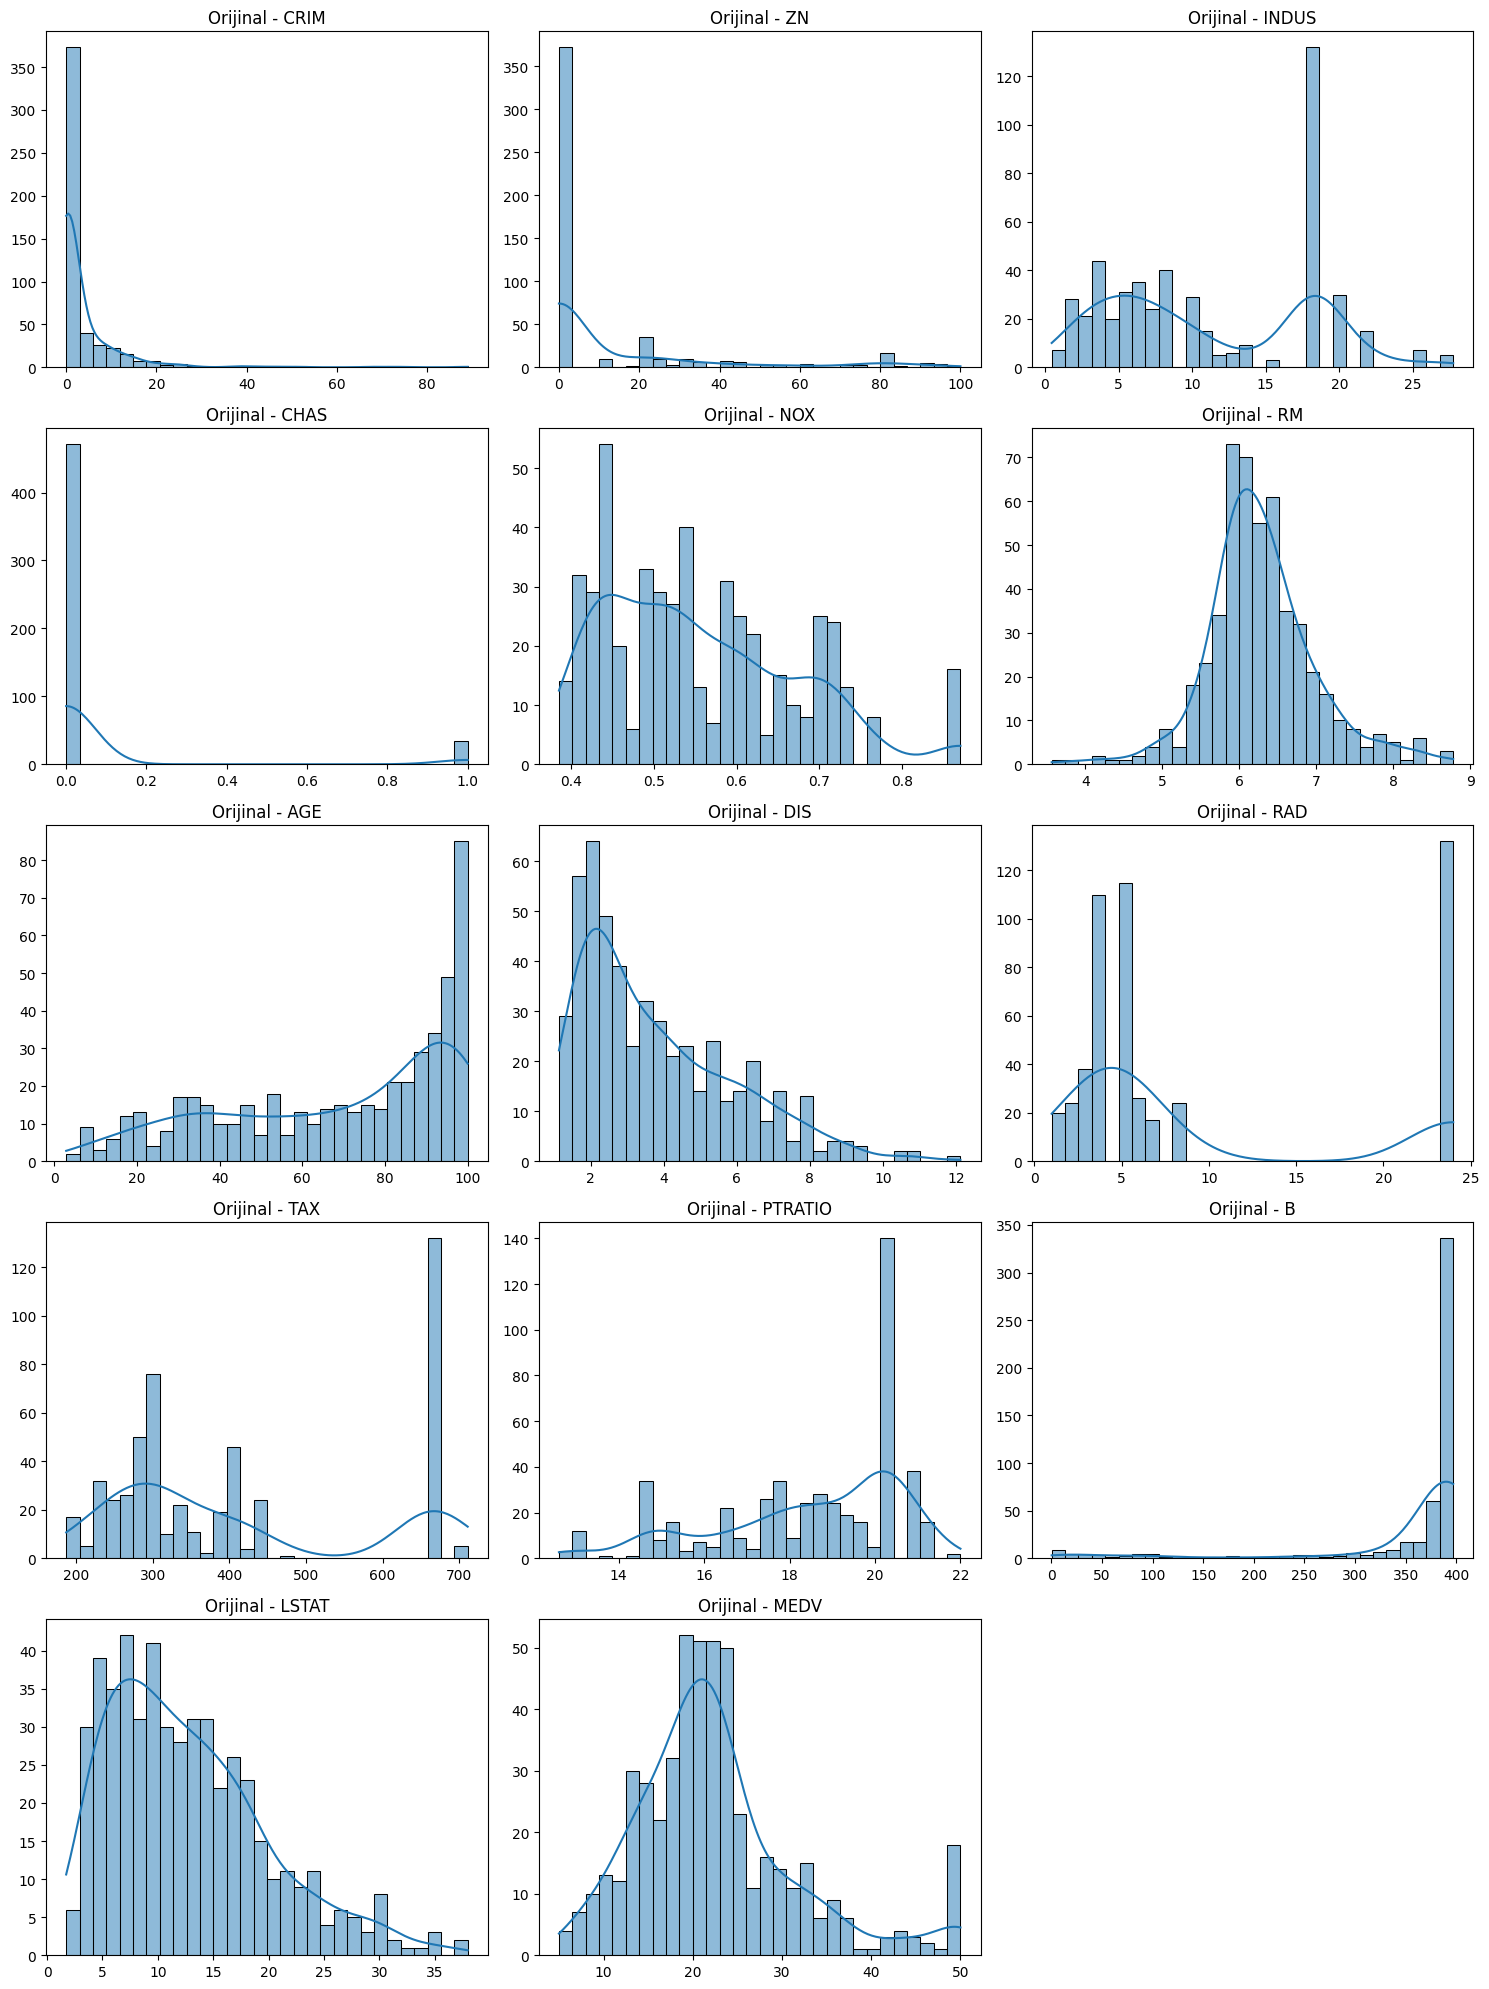

In [10]:
plot_all_histograms(df , title_prefix="Orijinal - ")

In [11]:
from scipy.stats import skew

In [12]:
#bir tarafa çok yatkın olan dağılımları numeric olarak ölçebilen bir kütüphane

In [13]:
df.apply(skew).sort_values(ascending=False)

CRIM       5.207652
CHAS       3.395799
ZN         2.219063
MEDV       1.104811
DIS        1.008779
RAD        1.001833
LSTAT      0.903771
NOX        0.727144
TAX        0.667968
RM         0.402415
INDUS      0.294146
AGE       -0.597186
PTRATIO   -0.799945
B         -2.881798
dtype: float64

In [14]:
X=df.drop("MEDV", axis=1)
y=df["MEDV"]

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=15)

In [16]:
from sklearn.preprocessing import PowerTransformer

pt_X = PowerTransformer(method="yeo-johnson")

X_train_transformed = pt_X.fit_transform(X_train)
X_test_transformed = pt_X.transform(X_test)

In [17]:
X_train_transformed

array([[-0.90416687,  1.72442905, -1.21928149, ..., -1.42736186,
         0.42655296, -1.32224219],
       [ 1.60589558, -0.58861584,  1.01109951, ...,  0.84862157,
        -2.70363012,  2.13913358],
       [-0.92538322, -0.58861584, -1.49298742, ..., -0.50285738,
         0.35083483,  0.30369848],
       ...,
       [ 1.36644094, -0.58861584,  1.01109951, ...,  0.84862157,
         0.64303057,  1.01394471],
       [-0.63627473,  1.66478341, -0.67623356, ...,  0.15946872,
         0.40954532,  0.92286642],
       [ 1.2728377 , -0.58861584,  1.01109951, ...,  0.84862157,
        -2.70939829,  0.97834079]], shape=(404, 13))

In [18]:
#numpy dizisi olarak döndü çünkü sklearn kütüphanesi numpy dizisi ile çalışıyor

In [19]:
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'] #MEDV'yi çıkardık
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=column_names)

In [20]:
X_train_transformed_df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,-0.904167,1.724429,-1.219281,-0.267615,-1.133724,0.654830,-1.320696,1.297076,-0.255374,0.244488,-1.427362,0.426553,-1.322242
1,1.605896,-0.588616,1.011100,-0.267615,1.465402,-0.490305,0.689192,-1.115580,1.457243,1.370436,0.848622,-2.703630,2.139134
2,-0.925383,-0.588616,-1.492987,-0.267615,-0.496175,-0.175553,-0.053289,0.037511,-0.944274,-1.975622,-0.502857,0.350835,0.303698
3,0.999995,-0.588616,1.161199,-0.267615,2.026049,-0.985039,0.975581,-1.456339,-0.255374,0.275674,-1.555351,-0.550002,1.209644
4,-0.628294,-0.588616,0.138417,-0.267615,-1.475942,-0.043701,-1.910821,0.936406,-0.551621,-0.473029,0.216963,0.073562,-0.622936
...,...,...,...,...,...,...,...,...,...,...,...,...,...
399,1.668295,-0.588616,1.011100,-0.267615,1.072096,1.447764,1.100495,-1.734661,1.457243,1.370436,0.848622,0.643031,0.342306
400,-0.390949,-0.588616,1.382524,-0.267615,0.752694,-0.654775,0.996311,-0.517389,-0.551621,0.472960,1.592342,0.396688,0.542831
401,1.366441,-0.588616,1.011100,-0.267615,1.206460,0.184264,1.021234,-1.275079,1.457243,1.370436,0.848622,0.643031,1.013945
402,-0.636275,1.664783,-0.676234,-0.267615,-1.216540,-0.973231,-0.000938,1.644135,0.171014,-0.249768,0.159469,0.409545,0.922866


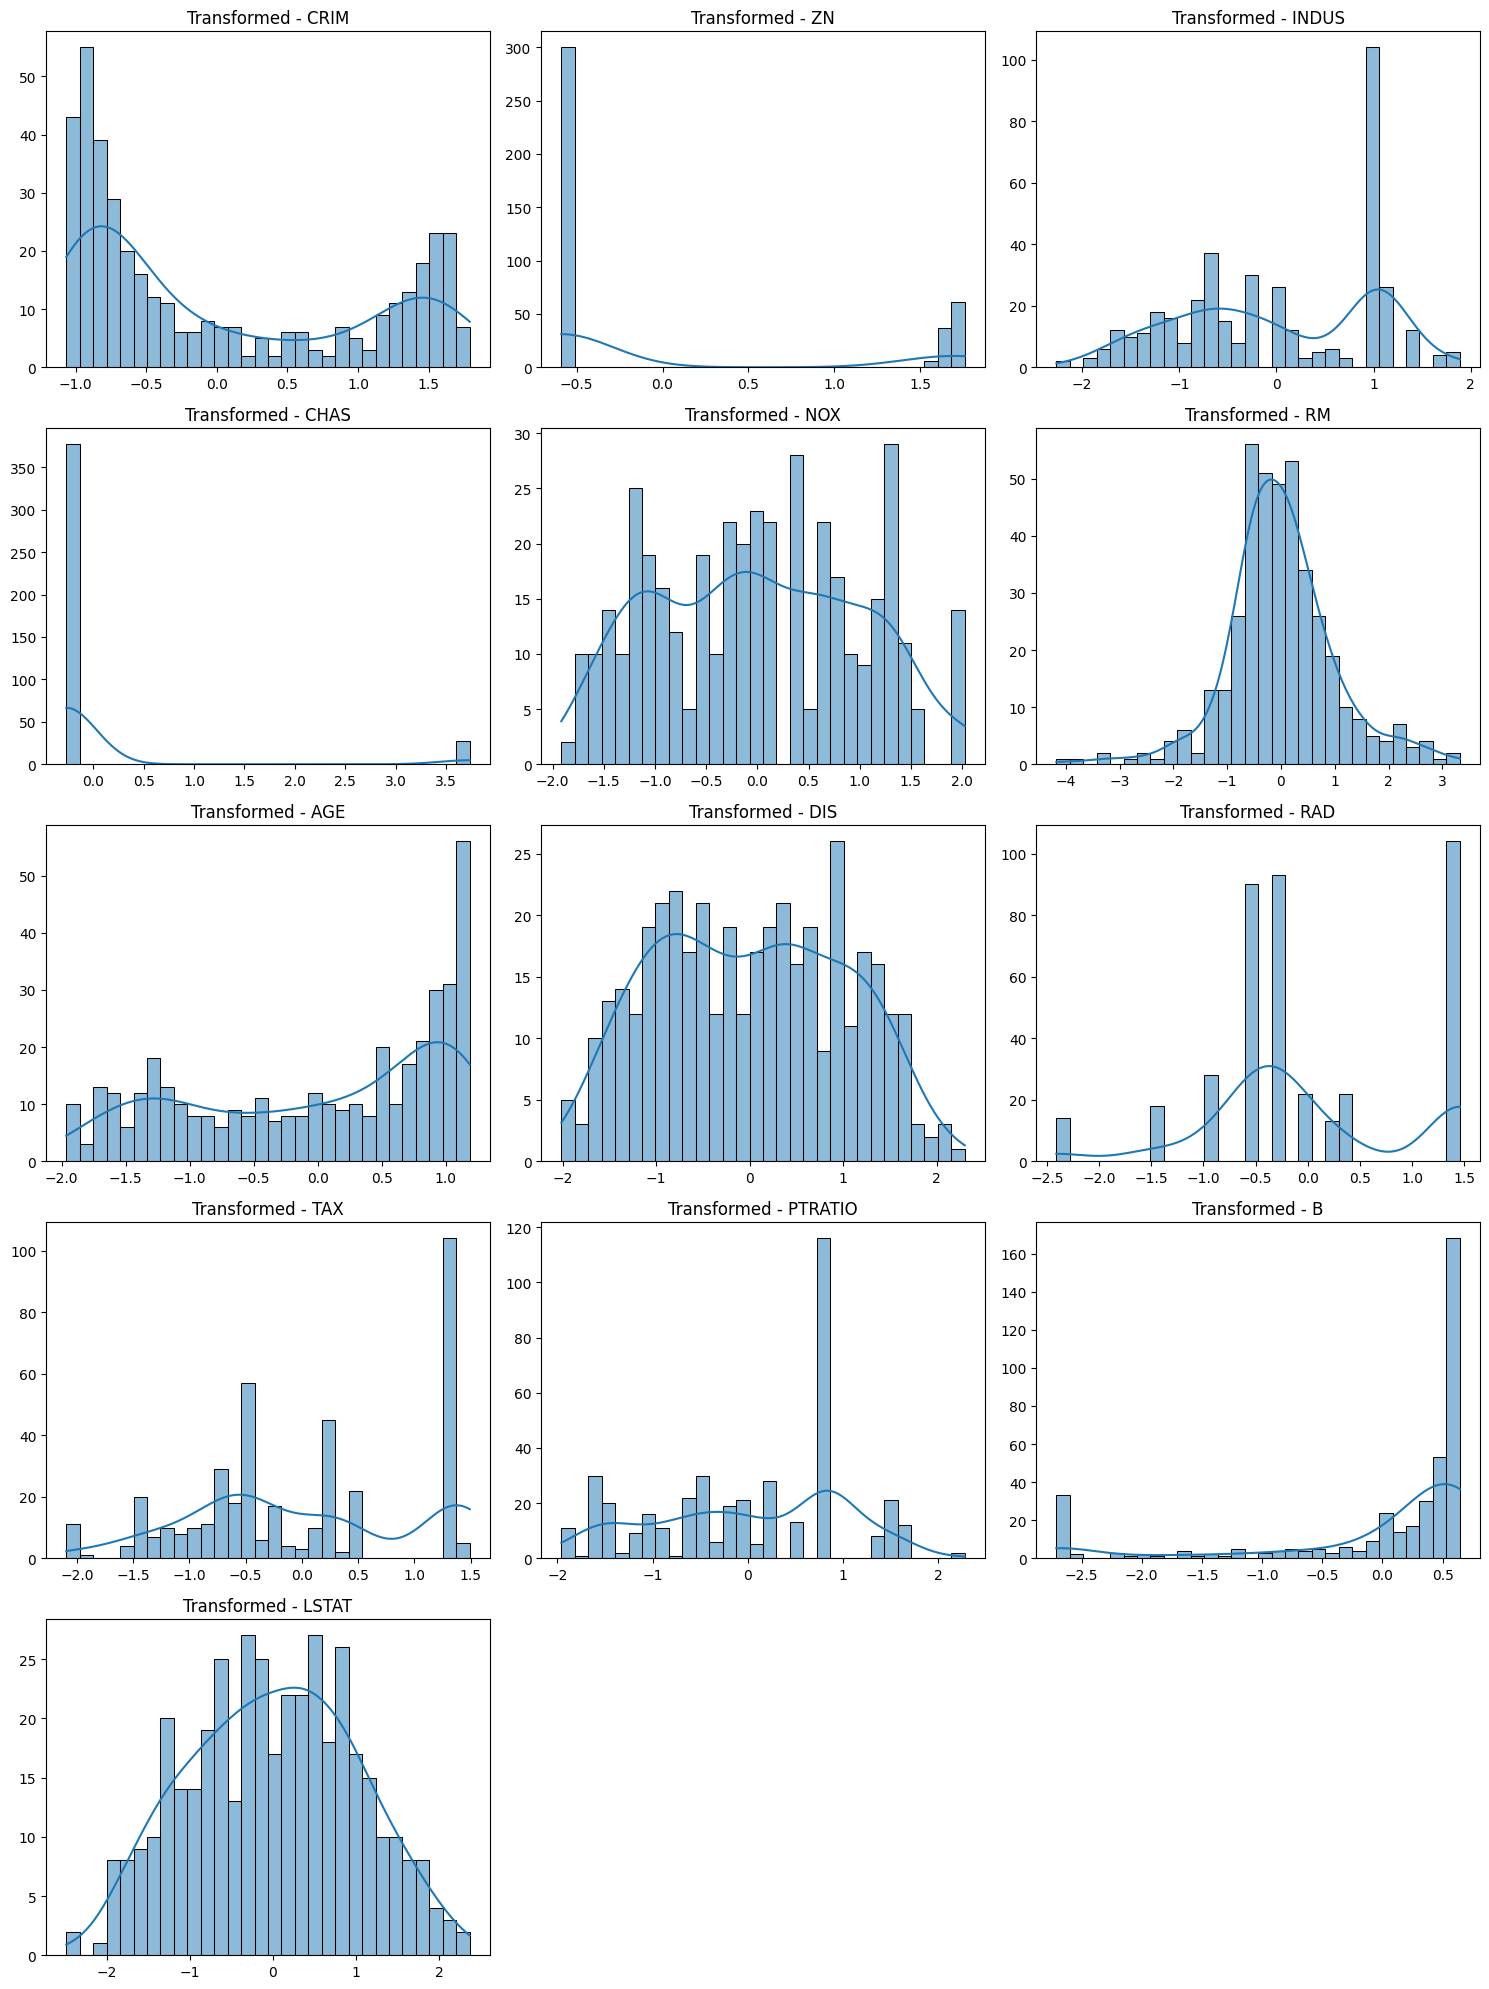

In [21]:
plot_all_histograms(X_train_transformed_df, title_prefix="Transformed - ")

In [22]:
df_clean1=df.copy()
kayit_yolu = r"C:\Users\merve\Desktop\PythonProject\Transformation\cleaned_23-boston.csv"
df_clean1.to_csv(kayit_yolu, index=False)
print(f"Temizlenmiş veri başarıyla kaydedildi: {kayit_yolu}")

Temizlenmiş veri başarıyla kaydedildi: C:\Users\merve\Desktop\PythonProject\Transformation\cleaned_23-boston.csv
